In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_parquet(r"D:\yield_curve_forecast\data\processed\yield_curve_data.parquet")
df = df.set_index("observation_date")

In [3]:
df.head()

,CPIAUCSL,CPILFESL,DCOILWTICO,DGS1,DGS10,DGS2,DGS30,DGS3MO,DGS5,FEDFUNDS,GDPC1,HOUST,ICSA,INDPRO,RSAFS,UMCSENT,UNRATE,VIXCLS
observation_date,,,,,,,,,,,,,,,,,,
1992-01-01,138.3,145.1,18.93,4.23,7.31,5.11,7.77,3.94,6.44,4.03,10236.435,1176,439000.0,61.4616,159177,67.5,7.3,17.40
1992-02-01,138.6,145.4,18.69,4.35,7.27,5.27,7.80,4.03,6.58,4.06,10236.435,1250,442200.0,61.8955,159189,68.8,7.4,16.68
1992-03-01,139.1,145.9,19.49,4.54,7.54,5.60,7.96,4.15,6.94,3.98,10236.435,1297,429500.0,62.4232,158647,76.0,7.4,16.18
1992-04-01,139.4,146.3,20.88,4.40,7.61,5.46,8.06,3.79,6.91,3.73,10347.429,1099,418250.0,62.8970,159921,77.2,7.4,15.53
1992-05-01,139.7,146.8,22.13,4.24,7.33,5.19,7.84,3.79,6.61,3.82,10347.429,1214,417400.0,63.1040,160471,79.2,7.6,13.86


In [4]:
df.dtypes

CPIAUCSL      float64
CPILFESL      float64
DCOILWTICO    float64
DGS1          float64
DGS10         float64
DGS2          float64
DGS30         float64
DGS3MO        float64
DGS5          float64
FEDFUNDS      float64
GDPC1         float64
HOUST           int64
ICSA          float64
INDPRO        float64
RSAFS           int64
UMCSENT       float64
UNRATE        float64
VIXCLS        float64
dtype: object

In [5]:
df.describe()

,CPIAUCSL,CPILFESL,DCOILWTICO,DGS1,DGS10,DGS2,DGS30,DGS3MO,DGS5,FEDFUNDS,GDPC1,HOUST,ICSA,INDPRO,RSAFS,UMCSENT,UNRATE,VIXCLS
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.00000,405.000000,405.000000,405.000000,405.000000,405.000000,4.050000e+02,405.000000,405.000000,405.000000,405.000000,405.000000
mean,213.962252,220.012005,53.306840,2.769235,4.000568,2.987432,4.53484,2.554667,3.502667,2.633852,16692.337170,1338.683951,3.656283e+05,91.929425,379012.219753,84.976049,5.650370,19.460716
std,48.935716,47.509274,29.141445,2.126342,1.744233,2.100093,1.60693,2.127779,1.919190,2.175269,3701.181601,383.975748,2.846234e+05,11.207278,151557.819880,13.893577,1.781681,7.569615
min,138.300000,145.100000,11.370000,0.050000,0.550000,0.110000,1.20000,0.000000,0.210000,0.050000,10236.435000,478.000000,1.975000e+05,61.461600,158647.000000,50.000000,3.400000,9.510000
25%,172.200000,181.100000,24.870000,0.480000,2.510000,0.860000,3.09000,0.180000,1.750000,0.190000,14130.908000,1140.000000,2.740000e+05,88.379300,266885.000000,74.300000,4.300000,13.700000
50%,213.942000,216.925000,51.670000,2.460000,4.000000,2.860000,4.53000,2.190000,3.530000,2.280000,16713.314000,1375.000000,3.320000e+05,95.954900,353285.000000,88.100000,5.200000,17.400000
75%,244.006000,251.227000,75.330000,4.880000,5.360000,4.790000,5.70000,4.770000,4.970000,4.940000,19398.343000,1584.000000,3.820000e+05,100.327300,464284.000000,95.300000,6.500000,23.500000
max,324.245000,330.418000,139.960000,7.200000,7.910000,7.690000,8.06000,6.380000,7.830000,6.540000,24026.834000,2273.000000,4.663250e+06,104.100400,732192.000000,112.000000,14.800000,59.890000


In [6]:
yield_col = ["DGS3MO", "DGS1", "DGS2", "DGS5", "DGS10", "DGS30"]
macro_col = [X for X in df.columns if X not in yield_col]
df.shape

(405, 18)

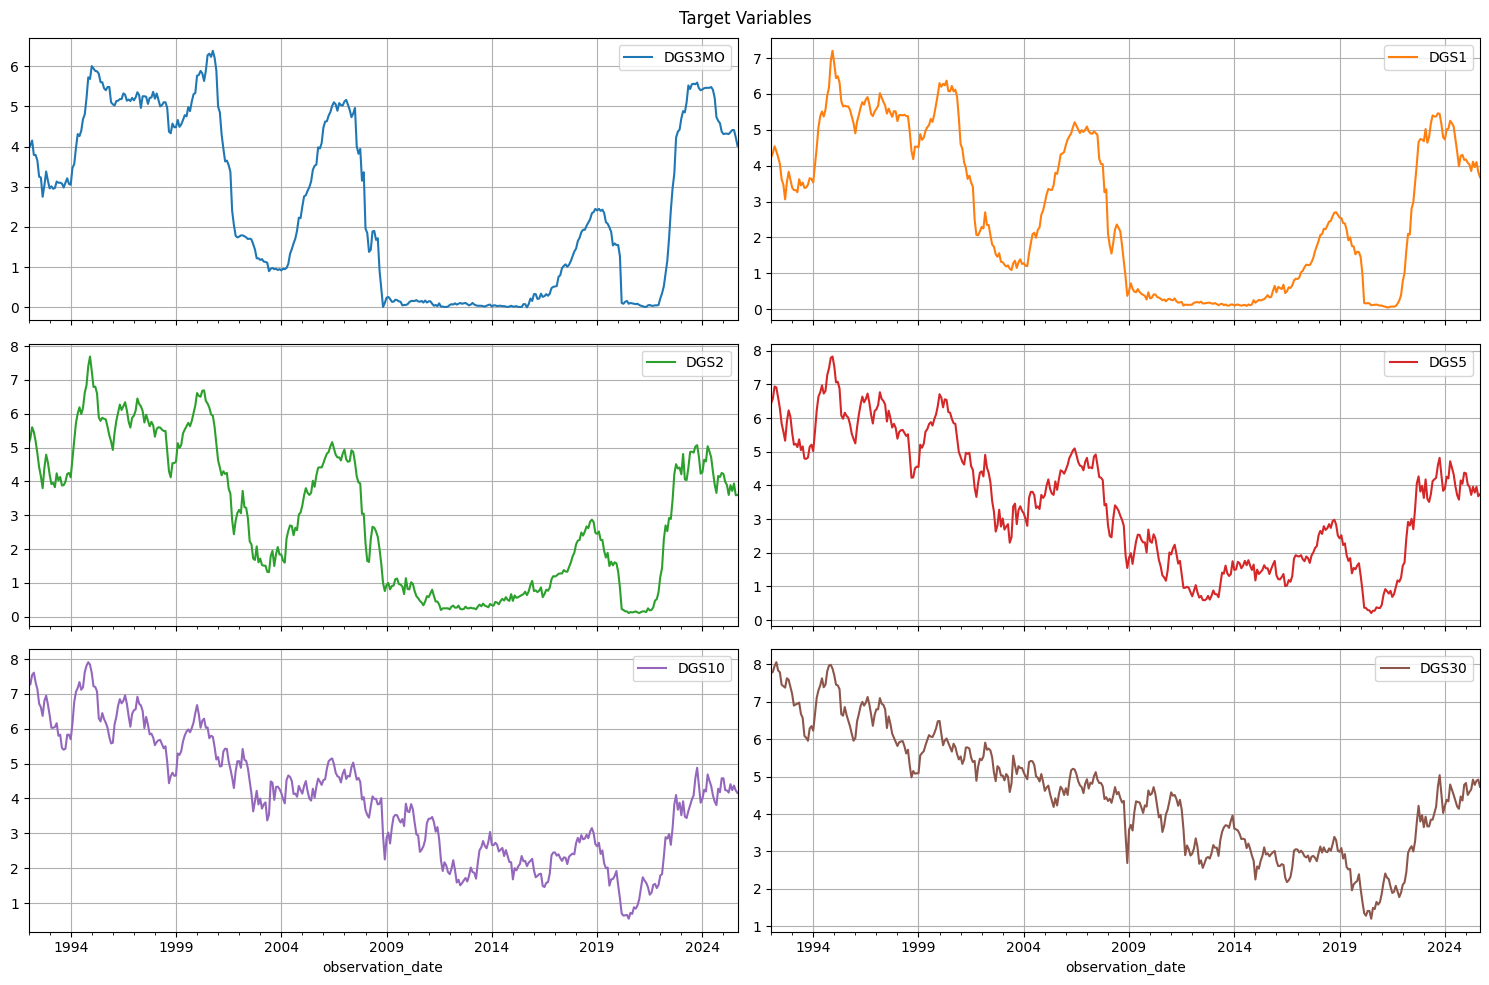

In [7]:
# Plots all target columns
df[yield_col].plot(
    subplots=True,
    layout=(-1, 2),  # -1 automatically calculates the required number of rows
    figsize=(15, 10),
    title="Target Variables",
    grid=True,
)

plt.tight_layout()
plt.show()

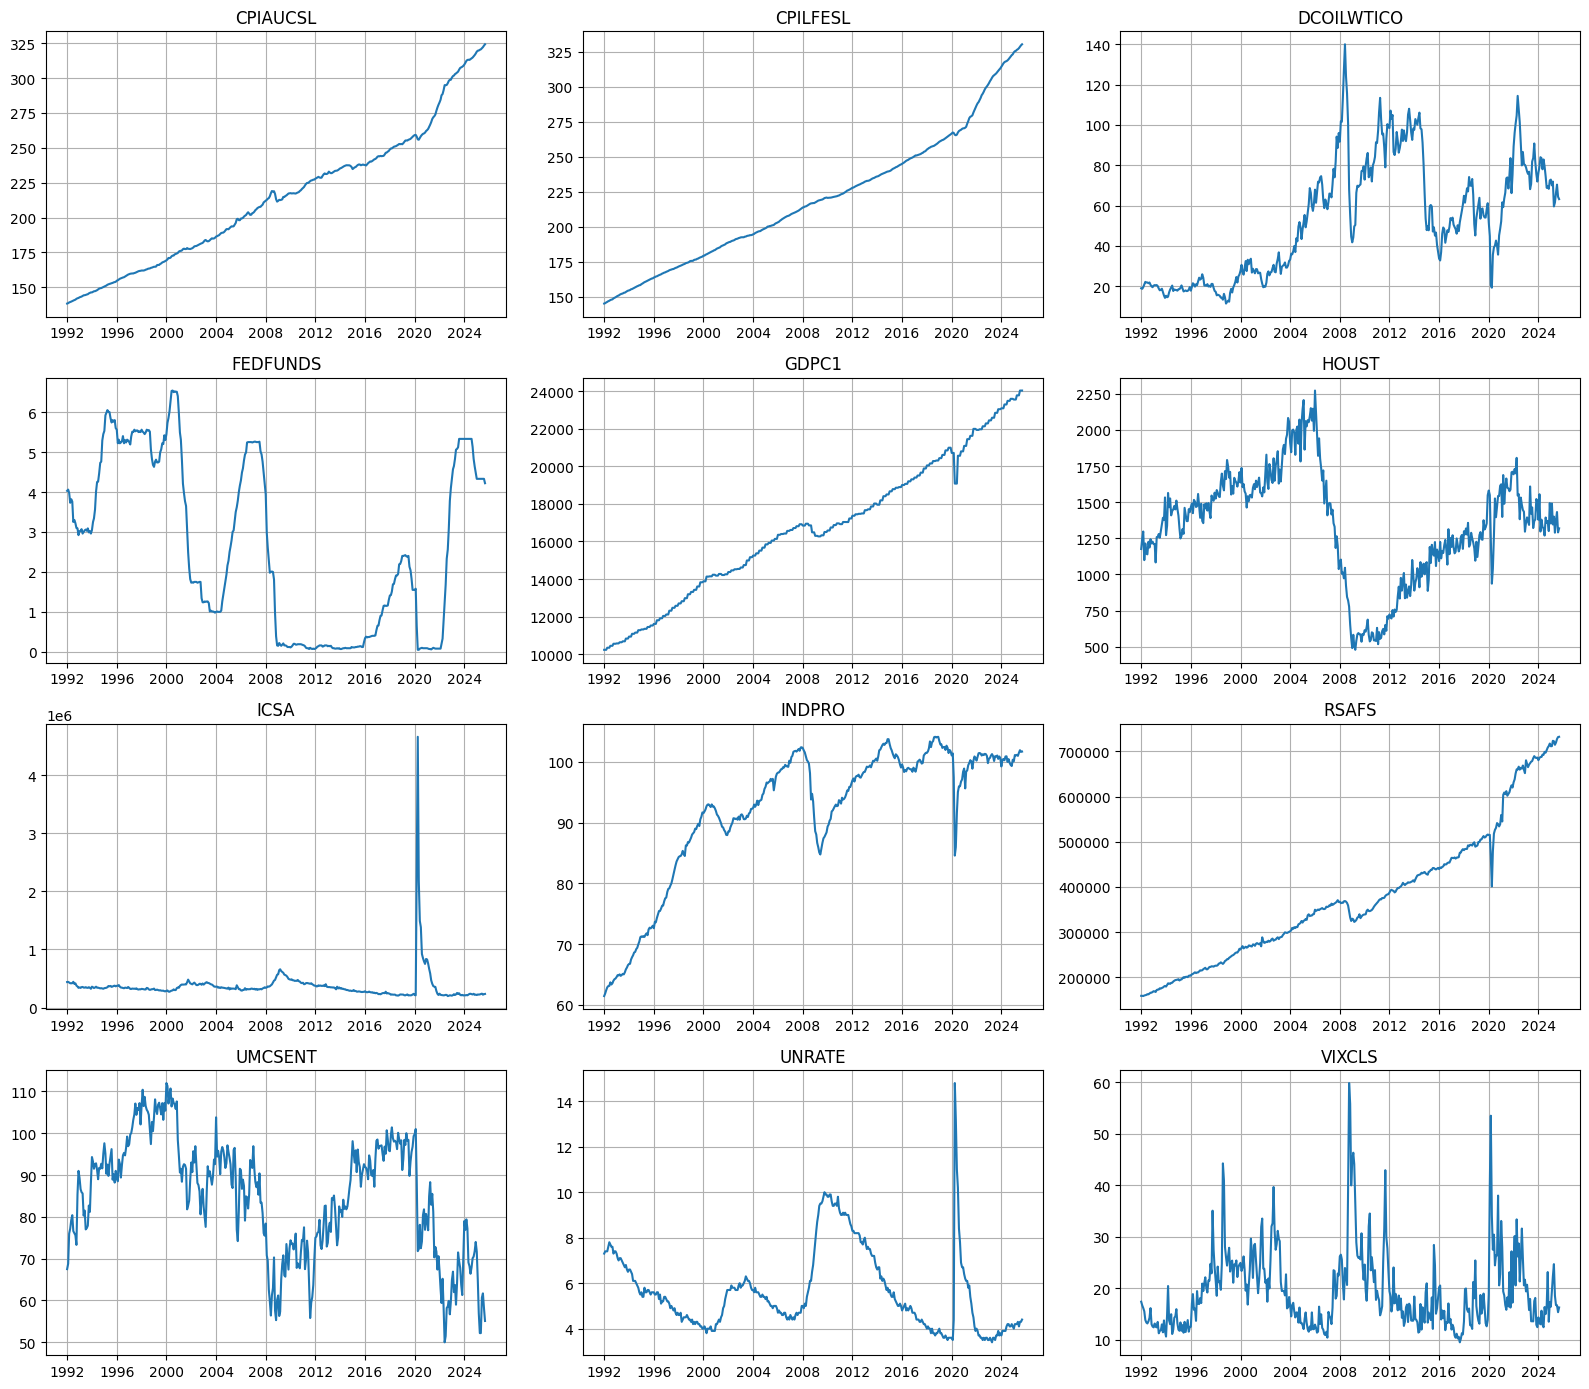

In [8]:
fig, ax = plt.subplots(4, 3, figsize=(16, 14))

ax = ax.ravel()

for i, col in enumerate(macro_col):
    ax[i].plot(df.index, df[col], linewidth=1.5)
    ax[i].set_title(col)
    ax[i].grid(True)

plt.tight_layout()
plt.show()

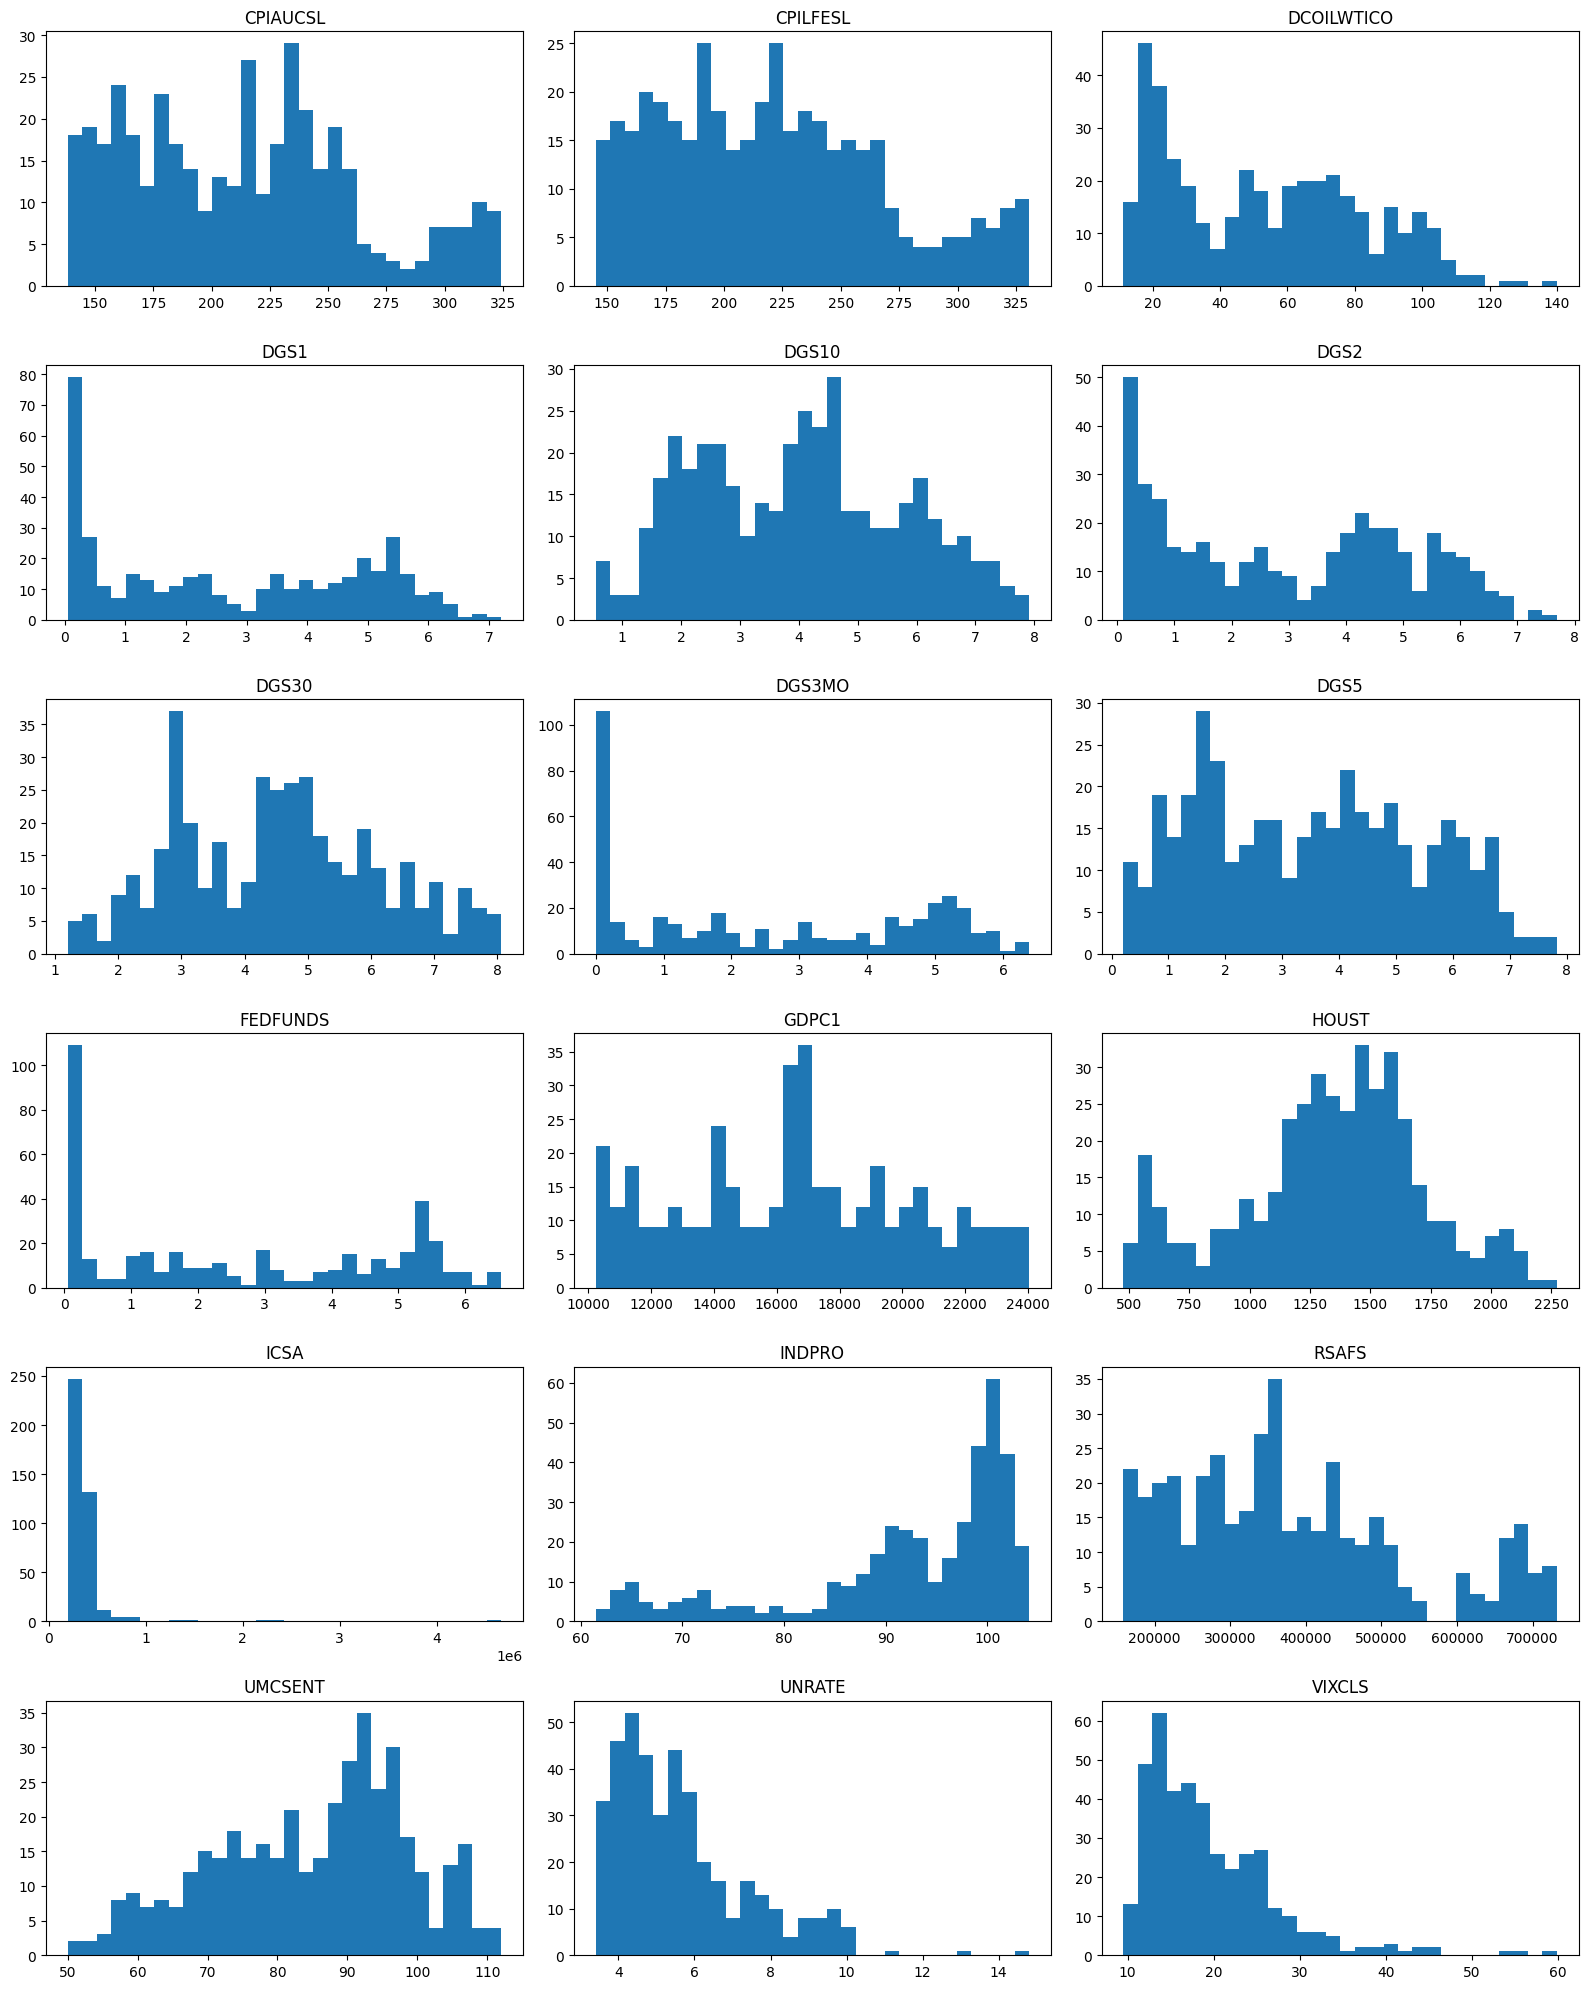

In [9]:
fig, ax = plt.subplots(6, 3, figsize=(16, 20))

ax = ax.ravel()

for i, col in enumerate(df.columns):
    ax[i].hist(df[col], bins=30)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

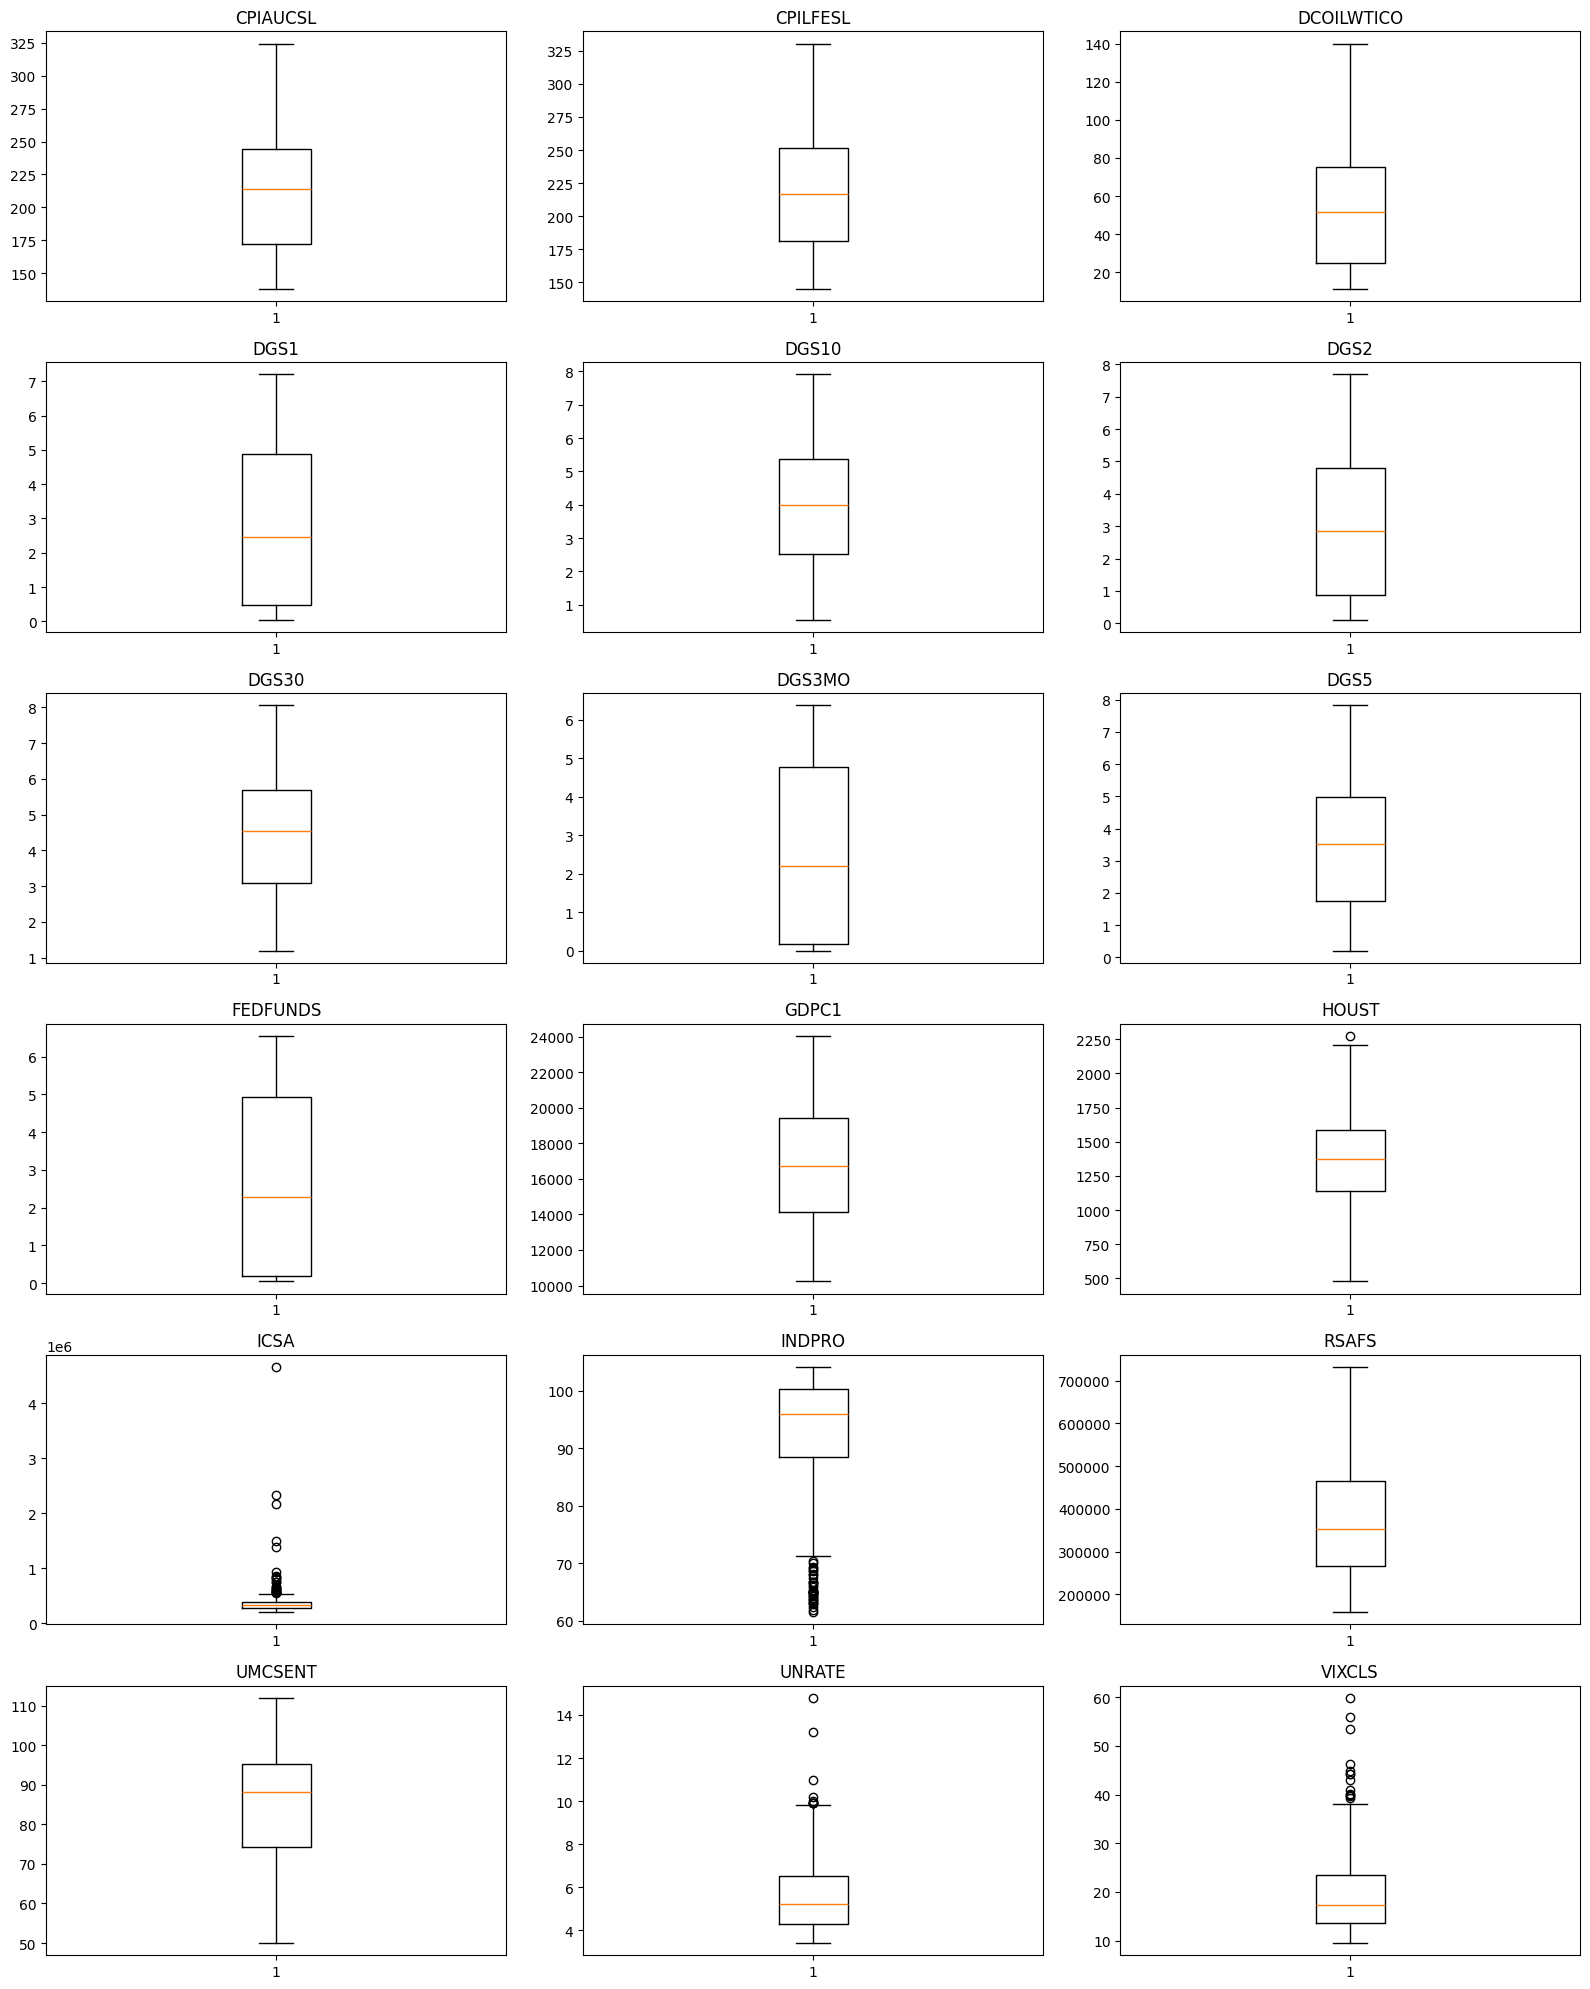

In [10]:
fig, ax = plt.subplots(6, 3, figsize=(16, 20))

ax = ax.ravel()

for i, col in enumerate(df.columns):
    ax[i].boxplot(df[col].dropna())
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

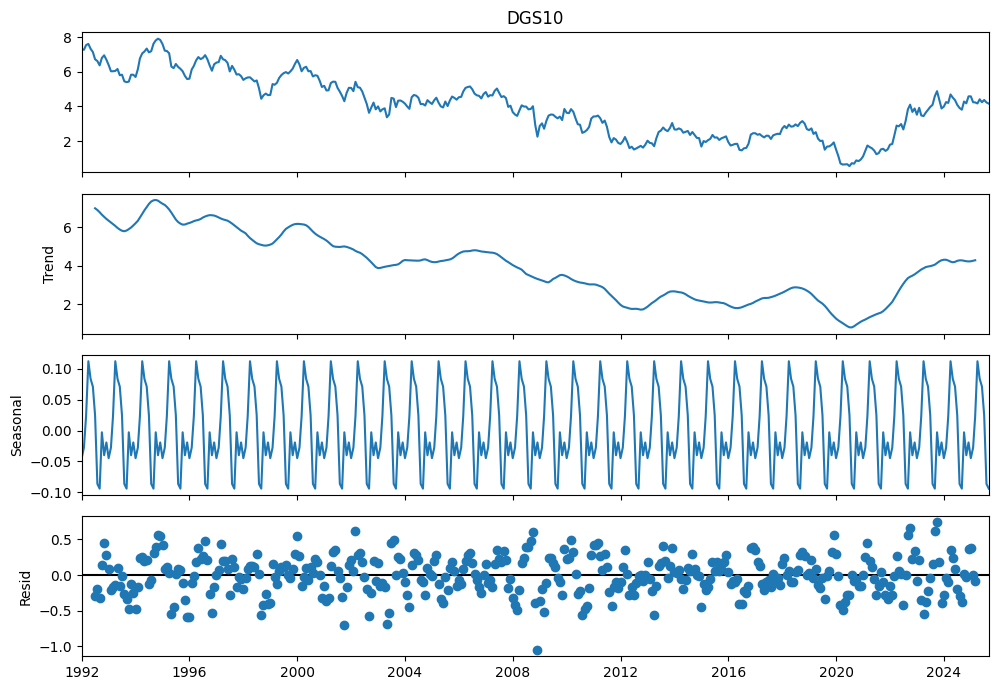

seasonal std / series std = 0.036
Near zero => seasonality is negligible; the trend (a unit root) dominates.


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Illustrative only: decompose a yield into trend / seasonal / residual.
# Expectation: trend dominates, seasonal is negligible — bond yields have no
# real seasonal cycle (this is WHY the FRED series are NSA and why we use
# ARIMA/VAR rather than leaning on SARIMA for the yields).
dec = seasonal_decompose(df["DGS10"].dropna(), model="additive", period=12)
fig = dec.plot(); fig.set_size_inches(10, 7); plt.tight_layout(); plt.show()

seasonal_share = dec.seasonal.std() / df["DGS10"].std()
print(f"seasonal std / series std = {seasonal_share:.3f}")
print("Near zero => seasonality is negligible; the trend (a unit root) dominates.")

In [12]:
from scipy.stats import kruskal
from statsmodels.tsa.stattools import acf

def seasonality_test(series, seasonal_lag=12, name=""):
    s = series.dropna()
    months = s.index.month

    groups = [s[months == m].values for m in range(1, 13)]
    groups = [g for g in groups if len(g) > 0]
    kw_stat, kw_p = kruskal(*groups)

    acf_vals = acf(s, nlags=seasonal_lag, fft=True)
    band = 1.96 / np.sqrt(len(s))
    seasonal_acf = acf_vals[seasonal_lag]

    return {
        "series": name,
        "KW_stat": kw_stat, "KW_p": kw_p,
        "seasonal_KW (p<0.05)": kw_p < 0.05,
        f"ACF_lag{seasonal_lag}": seasonal_acf,
        "band_95%": band,
        "seasonal_ACF (|acf|>band)": abs(seasonal_acf) > band,
    }

rows = []
for col in yield_col:
    rows.append(seasonality_test(df[col].diff(), name=col))   # diff() computed here directly
for col in macro_col:
    rows.append(seasonality_test(df[col].diff(), name=col))

seasonality_tbl = pd.DataFrame(rows).set_index("series")
print(seasonality_tbl.round(4))

             KW_stat    KW_p  seasonal_KW (p<0.05)  ACF_lag12  band_95%  \
series                                                                    
DGS3MO       29.7360  0.0017                  True     0.0924    0.0975   
DGS1         13.9721  0.2345                 False     0.0030    0.0975   
DGS2         12.7529  0.3098                 False     0.0277    0.0975   
DGS5         16.5754  0.1211                 False     0.0399    0.0975   
DGS10        18.7076  0.0665                 False     0.0020    0.0975   
DGS30        20.4901  0.0391                  True    -0.0365    0.0975   
CPIAUCSL      9.6848  0.5589                 False     0.0407    0.0975   
CPILFESL      7.4541  0.7612                 False     0.3486    0.0975   
DCOILWTICO   16.6140  0.1198                 False    -0.0555    0.0975   
FEDFUNDS     15.6983  0.1527                 False     0.0707    0.0975   
GDPC1       251.6201  0.0000                  True     0.0922    0.0975   
HOUST         5.9266  0.8

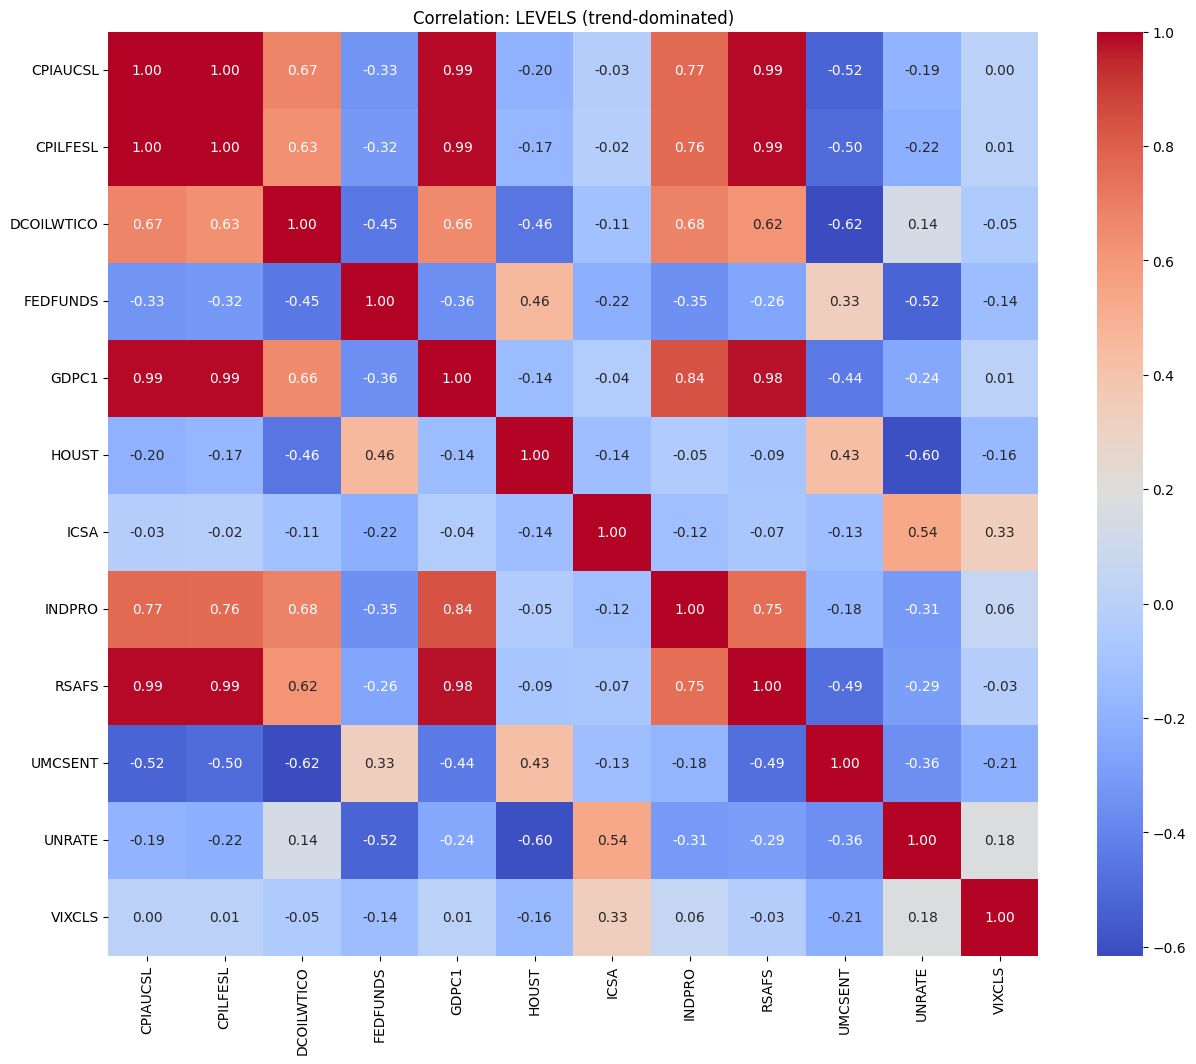

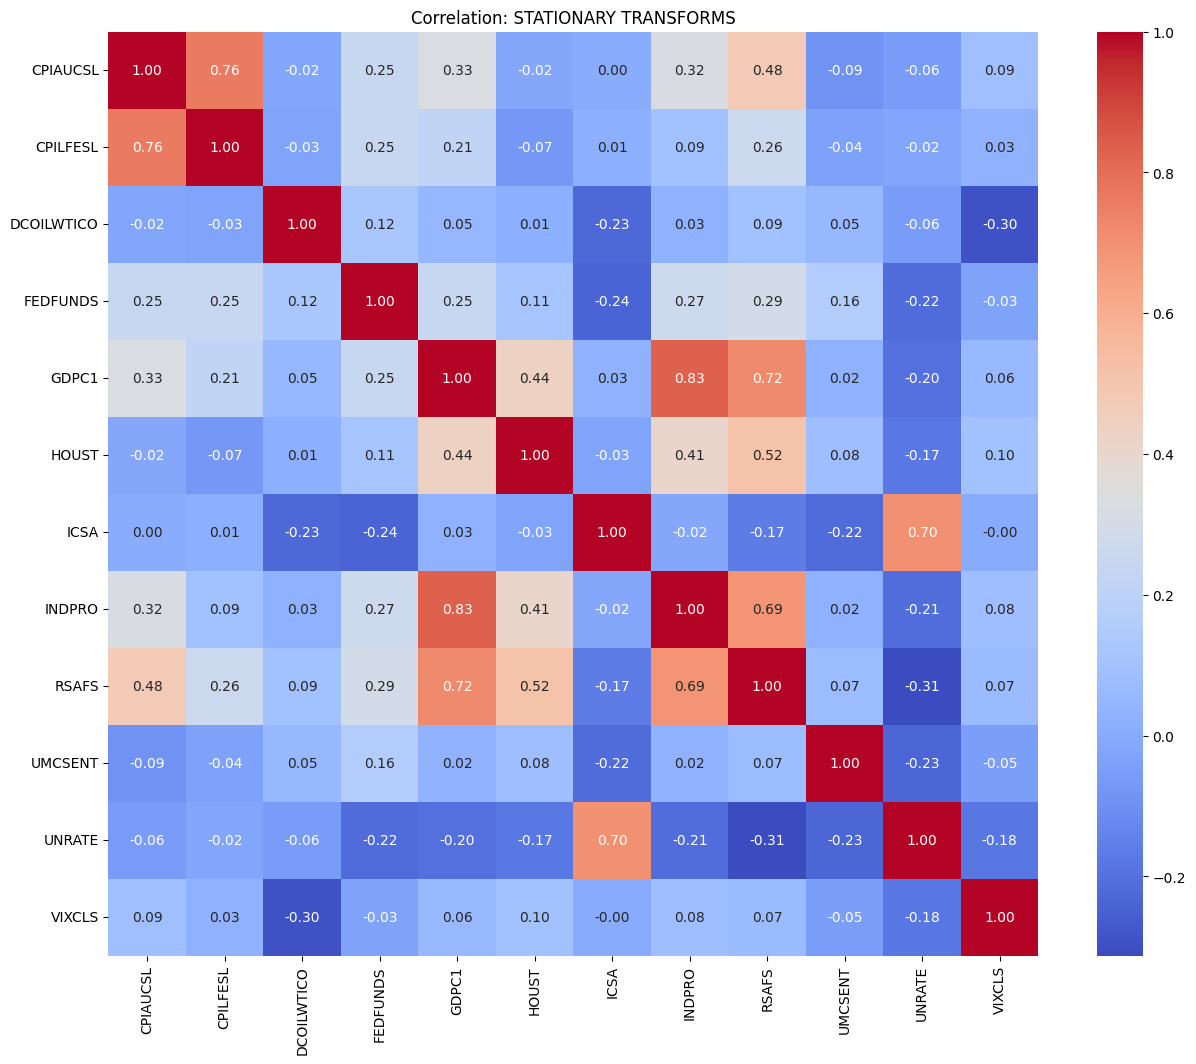

In [13]:
# LEVELS: dominated by shared trends -> often spurious. Labelled honestly.
plt.figure(figsize=(15, 12))
sns.heatmap(df[macro_col].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: LEVELS (trend-dominated)")
plt.show()

# STATIONARY transforms: the economically meaningful co-movement.
stat = pd.DataFrame(index=df.index)
for col in macro_col:
    if col in ("CPIAUCSL", "CPILFESL", "GDPC1", "INDPRO", "RSAFS", "HOUST"):
        stat[col] = df[col].pct_change(12) * 100   # YoY % for index/level series
    else:
        stat[col] = df[col].diff()                 # first difference for rates
plt.figure(figsize=(15, 12))
sns.heatmap(stat.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: STATIONARY TRANSFORMS")
plt.show()

In [14]:
print(df.isna().sum())

CPIAUCSL      0
CPILFESL      0
DCOILWTICO    0
DGS1          0
DGS10         0
DGS2          0
DGS30         0
DGS3MO        0
DGS5          0
FEDFUNDS      0
GDPC1         0
HOUST         0
ICSA          0
INDPRO        0
RSAFS         0
UMCSENT       0
UNRATE        0
VIXCLS        0
dtype: int64


In [15]:
summary = df.describe().T

print(summary)

            count           mean            std          min          25%  \
CPIAUCSL    405.0     213.962252      48.935716     138.3000     172.2000   
CPILFESL    405.0     220.012005      47.509274     145.1000     181.1000   
DCOILWTICO  405.0      53.306840      29.141445      11.3700      24.8700   
DGS1        405.0       2.769235       2.126342       0.0500       0.4800   
DGS10       405.0       4.000568       1.744233       0.5500       2.5100   
DGS2        405.0       2.987432       2.100093       0.1100       0.8600   
DGS30       405.0       4.534840       1.606930       1.2000       3.0900   
DGS3MO      405.0       2.554667       2.127779       0.0000       0.1800   
DGS5        405.0       3.502667       1.919190       0.2100       1.7500   
FEDFUNDS    405.0       2.633852       2.175269       0.0500       0.1900   
GDPC1       405.0   16692.337170    3701.181601   10236.4350   14130.9080   
HOUST       405.0    1338.683951     383.975748     478.0000    1140.0000   

## Feature Engineering

In [16]:
# Typical publication lags (in months)
publication_lag = {
    "CPIAUCSL": 1, "CPILFESL": 1,      # released ~2 weeks into next month
    "UNRATE": 1,                        # first Friday of next month
    "GDPC1": 1,                         # advance estimate ~1 month after quarter end
    "INDPRO": 1, "RSAFS": 1, "HOUST": 1,
    "FEDFUNDS": 1,                      
    "VIXCLS": 0, "DCOILWTICO": 0,       # market data, same-day
    "ICSA": 1,                          
}

for col, lag in publication_lag.items():
    if lag > 0 and col in df.columns:
        df[col] = df[col].shift(lag)

In [17]:
# Headline inflation
df["INFLATION_YOY"] = df["CPIAUCSL"].pct_change(12) * 100

# Core inflation
df["CORE_INFLATION_YOY"] = df["CPILFESL"].pct_change(12) * 100

In [18]:
df["GDP_GROWTH_YOY"] = df["GDPC1"].pct_change(12) * 100

In [19]:
df["INDPRO_GROWTH_YOY"] = df["INDPRO"].pct_change(12) * 100
df["RSAFS_GROWTH_YOY"] = df["RSAFS"].pct_change(12) * 100
df["HOUST_GROWTH_YOY"] = df["HOUST"].pct_change(12) * 100

In [20]:
for col in yield_col:
    df[f"{col}_CHANGE"] = df[col].diff()

In [21]:
df["SPREAD_10Y_2Y"] = df["DGS10"] - df["DGS2"]
df["SPREAD_10Y_3M"] = df["DGS10"] - df["DGS3MO"]
df["SPREAD_30Y_10Y"] = df["DGS30"] - df["DGS10"]
df["SPREAD_5Y_2Y"] = df["DGS5"] - df["DGS2"]
df["SPREAD_2Y_3M"] = df["DGS2"] - df["DGS3MO"]

In [22]:
df["SPREAD_10Y_2Y_LAG1"] = df["SPREAD_10Y_2Y"].shift(1)
df["SPREAD_10Y_2Y_LAG3"] = df["SPREAD_10Y_2Y"].shift(3)

# Campbell-Shiller style check: does today's spread predict next period's yield change?
df["DGS10_CHANGE_FWD1"] = df["DGS10_CHANGE"].shift(-1)  # for later regression testing only, not a model feature

In [23]:
df["FEDFUNDS_CHANGE"] = df["FEDFUNDS"].diff()
df["UNRATE_CHANGE"] = df["UNRATE"].diff()
df["VIX_CHANGE"] = df["VIXCLS"].diff()
df["WTI_CHANGE"] = df["DCOILWTICO"].diff()
df["UMCSENT_CHANGE"] = df["UMCSENT"].diff()

In [24]:
df["CURVE_LEVEL"] = df[yield_col].mean(axis=1)
df["CURVE_SLOPE"] = df["DGS10"] - df["DGS3MO"]
df["CURVE_CURVATURE"] = (df["DGS2"]- ((df["DGS3MO"] + df["DGS10"]) / 2))

In [25]:
df["DGS2_FEDFUNDS_SPREAD"] = df["DGS2"] - df["FEDFUNDS"]
df["DGS10_FEDFUNDS_SPREAD"] =df["DGS10"] - df["FEDFUNDS"]

In [26]:
df["VIX_LOG"] = np.log(df["VIXCLS"])
df["WTI_LOG_RETURN"] = np.log(df["DCOILWTICO"] / df["DCOILWTICO"].shift(1))

In [27]:
lag_cols = ["INFLATION_YOY", "CORE_INFLATION_YOY", "GDP_GROWTH_YOY",
            "FEDFUNDS", "UNRATE", "VIX_LOG"] 

lags = [1, 3, 6, 12]

for col in lag_cols:
    for lag in lags:
        df[f"{col}_LAG{lag}"] = df[col].shift(lag)

## Time_Series Diagnostics

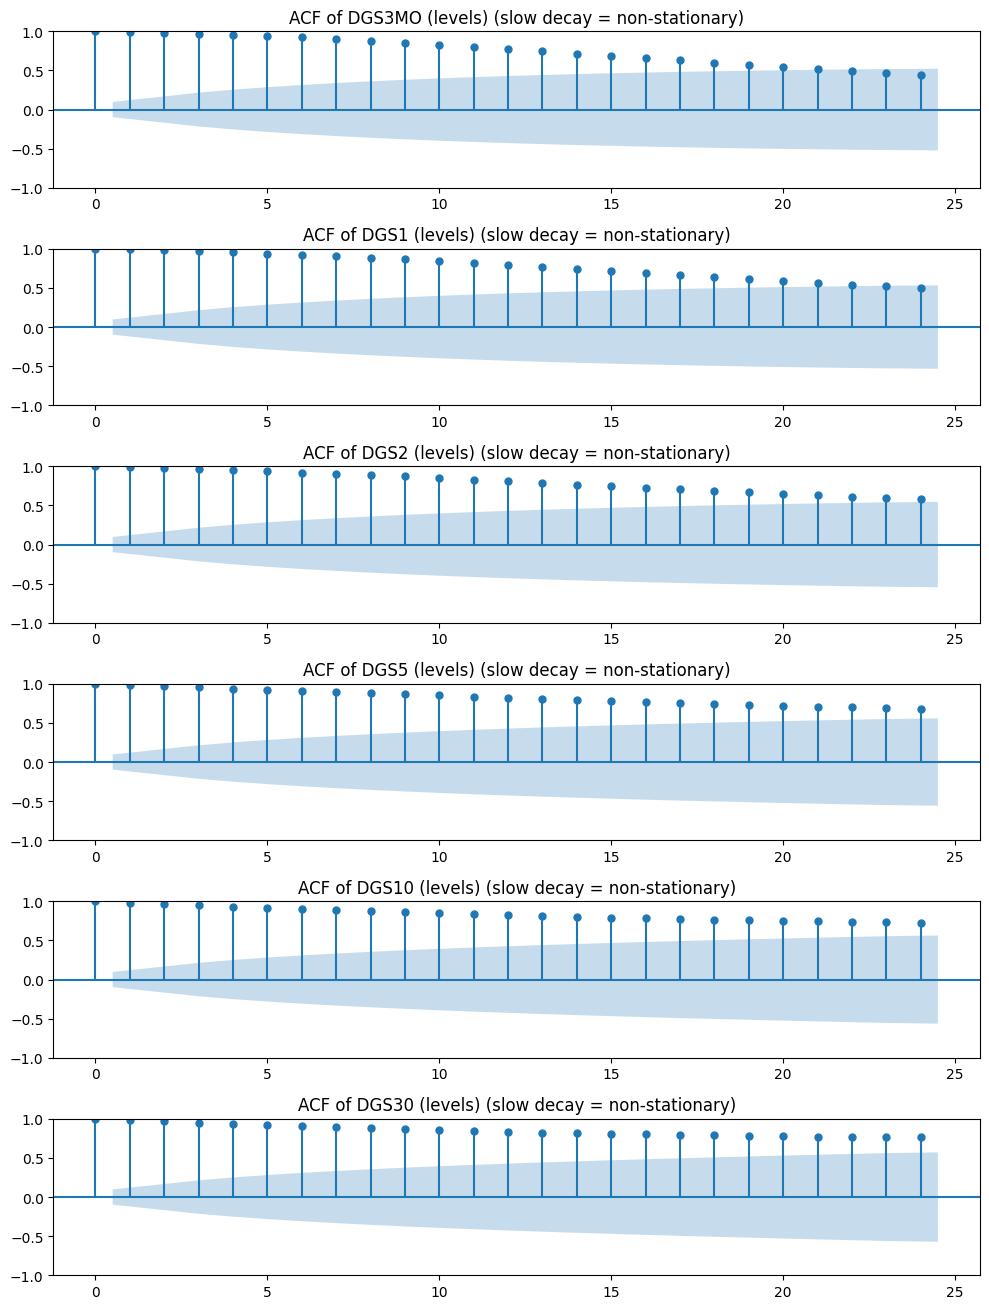

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Levels: ACF decays very slowly = classic non-stationary signature.
fig, axes = plt.subplots(len(yield_col), 1, figsize=(10, 2.2 * len(yield_col)))
for ax, col in zip(axes, yield_col):
    plot_acf(df[col].dropna(), lags=24, ax=ax)
    ax.set_title(f"ACF of {col} (levels) (slow decay = non-stationary)")
plt.tight_layout(); plt.show()

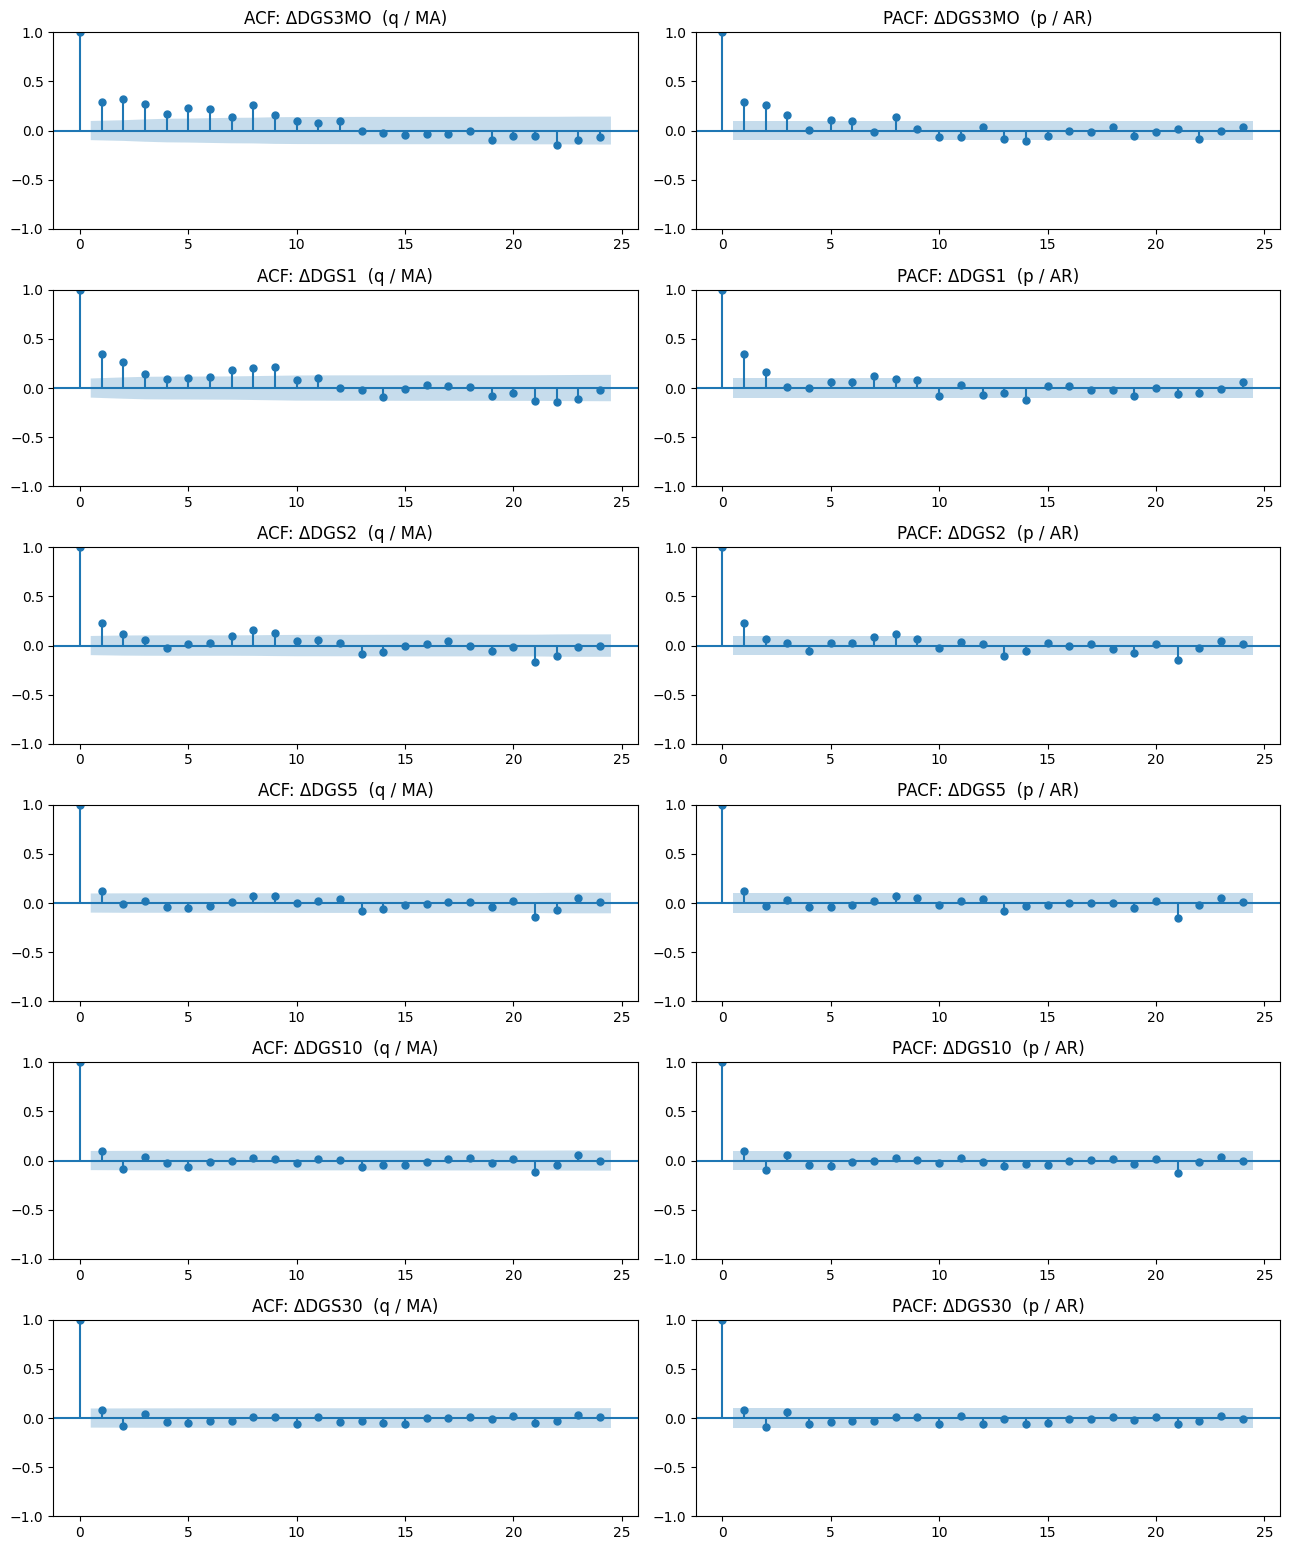

In [29]:
fig, axes = plt.subplots(len(yield_col), 2, figsize=(13, 2.6 * len(yield_col)))
for i, col in enumerate(yield_col):
    s = df[f"{col}_CHANGE"].dropna()
    plot_acf(s, lags=24, ax=axes[i, 0]);  axes[i, 0].set_title(f"ACF: Δ{col}  (q / MA)")
    plot_pacf(s, lags=24, ax=axes[i, 1], method="ywm"); axes[i, 1].set_title(f"PACF: Δ{col}  (p / AR)")
plt.tight_layout(); plt.show()

Explained variance:
  PC1: 76.87%  (cumulative 76.87%)
  PC2: 16.22%  (cumulative 93.09%)
  PC3:  4.89%  (cumulative 97.98%)
  PC4:  1.38%  (cumulative 99.35%)
  PC5:  0.45%  (cumulative 99.81%)
  PC6:  0.19%  (cumulative 100.00%)


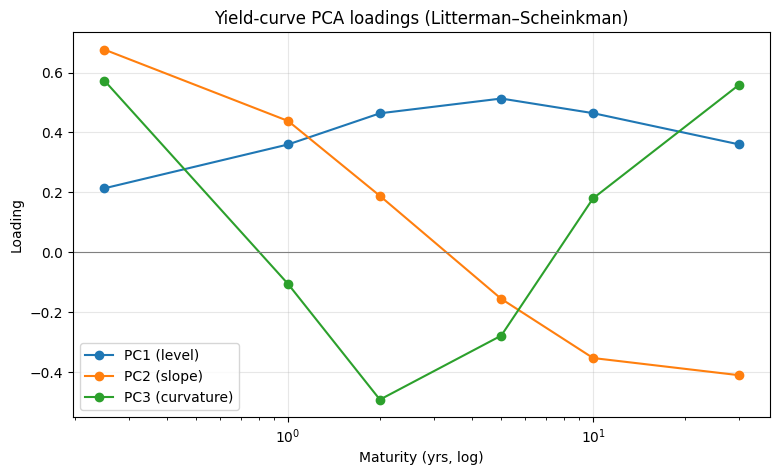

In [30]:
from sklearn.decomposition import PCA

change_cols = [f"{c}_CHANGE" for c in yield_col]
Y = df[change_cols].dropna()

pca = PCA(n_components=len(yield_col)).fit(Y)
evr = pca.explained_variance_ratio_
print("Explained variance:")
for i, v in enumerate(evr, 1):
    print(f"  PC{i}: {v:6.2%}  (cumulative {evr[:i].sum():6.2%})")

# PCA signs are arbitrary; interpret shape, not sign.
maturities = [0.25, 1, 2, 5, 10, 30]
plt.figure(figsize=(9, 5))
for j, name in enumerate(["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]):
    plt.plot(maturities, pca.components_[j], marker="o", label=name)
plt.axhline(0, color="grey", lw=0.8)
plt.xscale("log"); plt.xlabel("Maturity (yrs, log)"); plt.ylabel("Loading")
plt.title("Yield-curve PCA loadings (Litterman–Scheinkman)")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [31]:
ff = df["FEDFUNDS_CHANGE"]
for c in yield_col:
    print(f"corr(ΔFEDFUNDS, Δ{c}) = {ff.corr(df[f'{c}_CHANGE']):+.2f}")

corr(ΔFEDFUNDS, ΔDGS3MO) = +0.34
corr(ΔFEDFUNDS, ΔDGS1) = +0.27
corr(ΔFEDFUNDS, ΔDGS2) = +0.16
corr(ΔFEDFUNDS, ΔDGS5) = +0.09
corr(ΔFEDFUNDS, ΔDGS10) = +0.08
corr(ΔFEDFUNDS, ΔDGS30) = +0.08


### Multicollinearity

In [32]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

regressors = [
    "INFLATION_YOY", "CORE_INFLATION_YOY", "GDP_GROWTH_YOY",
    "INDPRO_GROWTH_YOY", "RSAFS_GROWTH_YOY", "HOUST_GROWTH_YOY",
    "FEDFUNDS", "UNRATE", "VIX_LOG", "ICSA", "DCOILWTICO",
]

threshold = 10.0
cols = regressors.copy()
frame = df[regressors].dropna()

# Repeatedly drop the single highest-VIF feature until all remaining are below threshold.
while len(cols) > 1:
    X = sm.add_constant(frame[cols])
    vifs = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    ).drop("const")

    if vifs.max() <= threshold:
        break

    drop = vifs.idxmax()
    print(f"drop {drop:20s} VIF={vifs.max():8.1f}")
    cols.remove(drop)

kept = cols
final_vif = vifs
print("\nKept:", kept)
print(final_vif.round(2).sort_values(ascending=False))


Kept: ['INFLATION_YOY', 'CORE_INFLATION_YOY', 'GDP_GROWTH_YOY', 'INDPRO_GROWTH_YOY', 'RSAFS_GROWTH_YOY', 'HOUST_GROWTH_YOY', 'FEDFUNDS', 'UNRATE', 'VIX_LOG', 'ICSA', 'DCOILWTICO']
GDP_GROWTH_YOY        5.74
INDPRO_GROWTH_YOY     5.38
INFLATION_YOY         4.37
RSAFS_GROWTH_YOY      3.41
CORE_INFLATION_YOY    3.19
UNRATE                2.98
FEDFUNDS              2.72
HOUST_GROWTH_YOY      1.91
DCOILWTICO            1.89
ICSA                  1.85
VIX_LOG               1.23
dtype: float64


In [33]:
print(df.isna().sum().sort_values(ascending=False).head(10))
first_valid = df.dropna().index.min()
print(f"First fully-valid row: {first_valid}")

GDP_GROWTH_YOY_LAG12        25
INFLATION_YOY_LAG12         25
CORE_INFLATION_YOY_LAG12    25
INFLATION_YOY_LAG6          19
GDP_GROWTH_YOY_LAG6         19
CORE_INFLATION_YOY_LAG6     19
INFLATION_YOY_LAG3          16
CORE_INFLATION_YOY_LAG3     16
GDP_GROWTH_YOY_LAG3         16
INFLATION_YOY_LAG1          14
dtype: int64
First fully-valid row: 1994-02-01 00:00:00


In [34]:
from pathlib import Path

# Forward-looking column is for the Campbell–Shiller test only and NOT a feature.
# Excluding it prevents look-ahead leakage into any training matrix.
leakage_cols = ["DGS10_CHANGE_FWD1"]
feature_matrix = df.drop(columns=[c for c in leakage_cols if c in df.columns])

# Trim burn-in: 12-month YoY + lag-12 features leave the first ~12–13 rows NaN.
first_valid = feature_matrix.dropna().index.min()
feature_matrix = feature_matrix.loc[first_valid:]

print(f"First fully-valid row: {first_valid.date()}")
print(f"Shape after trim     : {feature_matrix.shape}")
print(f"Remaining NaNs       : {int(feature_matrix.isna().sum().sum())}")   # want 0

out = Path(r"D:\yield_curve_forecast\data\processed")
out.mkdir(parents=True, exist_ok=True)
feature_matrix.to_parquet(out / "features.parquet")
feature_matrix.to_csv(out / "features.csv")
print("Saved → features.parquet / features.csv")

First fully-valid row: 1994-02-01
Shape after trim     : (380, 73)
Remaining NaNs       : 0
Saved → features.parquet / features.csv
